<a href="https://colab.research.google.com/github/jessicaromero-ctrl/Advanced-Math-for-ML/blob/main/Sesion7_Actividad3_PasosInferencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 7 · Actividad 3
# ¿Más pasos producen una mejor imagen?

**Curso:** Introducción a la Inteligencia Artificial Generativa    
**Modalidad:** laboratorio guiado en Google Colab

## Propósito
Descubrir cómo el número de **pasos de inferencia** afecta:

- el refinamiento de la imagen;
- la calidad percibida;
- el tiempo de generación;
- la aparición de rendimientos decrecientes.

> Solo cambiaremos el número de pasos. El prompt, la semilla, el Guidance Scale, el scheduler y el tamaño permanecerán constantes.


Preguntas iniciales:

- ¿Una imagen con 80 pasos será ocho veces mejor que una con 10?
- ¿En qué momento deja de valer la pena esperar?
- ¿Cómo se equilibra calidad y costo computacional?


# 0. Preparación del entorno

En Google Colab selecciona:

**Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU**

Después ejecuta las celdas en orden.


In [1]:
import torch

print("Versión de PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU detectada:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "No se detectó una GPU. Selecciona: "
        "Entorno de ejecución > Cambiar tipo de entorno de ejecución > T4 GPU."
    )


Versión de PyTorch: 2.11.0+cu128
GPU disponible: True
GPU detectada: Tesla T4


# 1. Configuración del guardado

Para guardar permanentemente en Google Drive cambia `USAR_DRIVE` a `True`.


In [2]:
from pathlib import Path

USAR_DRIVE = False

if USAR_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    CARPETA_RESULTADOS = Path(
        "/content/drive/MyDrive/IA_Generativa/Sesion7/Actividad3_PasosInferencia"
    )
else:
    CARPETA_RESULTADOS = Path("/content/Actividad3_PasosInferencia")

CARPETA_RESULTADOS.mkdir(parents=True, exist_ok=True)
print("Resultados:", CARPETA_RESULTADOS)


Resultados: /content/Actividad3_PasosInferencia


# 2. Instalación de bibliotecas

In [3]:
!pip -q install -U diffusers transformers accelerate safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 23.2 MB/s eta 0:00:00


# 3. Carga del modelo

Usaremos Stable Diffusion 1.5 con DPM-Solver. El scheduler permanecerá constante durante todo el experimento.


In [4]:
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
import matplotlib.pyplot as plt
import pandas as pd
import time

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    use_safetensors=True,
    safety_checker=None
)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_model_cpu_offload()
pipe.enable_attention_slicing()

print("Modelo cargado correctamente.")


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Modelo cargado correctamente.


# 4. Diseño del experimento

Constantes:

- Prompt: castillo medieval en las montañas;
- Semilla: 42;
- Guidance Scale: 7.5;
- Tamaño: 512 × 512;
- Scheduler: DPM-Solver.

Valores de pasos:

`5, 10, 20, 40 y 80`


In [5]:
PROMPT = "A medieval castle in the mountains at sunrise, cinematic, highly detailed"
SEED = 42
GUIDANCE = 7.5
WIDTH = 512
HEIGHT = 512
STEP_VALUES = [5, 10, 20, 40, 80]

def generar_imagen(num_steps):
    generator = torch.Generator(device="cuda").manual_seed(SEED)
    inicio = time.time()

    imagen = pipe(
        prompt=PROMPT,
        num_inference_steps=num_steps,
        guidance_scale=GUIDANCE,
        width=WIDTH,
        height=HEIGHT,
        generator=generator
    ).images[0]

    duracion = time.time() - inicio
    imagen.save(CARPETA_RESULTADOS / f"pasos_{num_steps}.png")
    return imagen, duracion


# 5. Predicción

Antes de ejecutar responde:

1. ¿Qué valor será claramente insuficiente?
2. ¿En qué número de pasos esperas una imagen aceptable?
3. ¿Habrá una diferencia evidente entre 40 y 80?
4. ¿Cuál tendrá la mejor relación calidad-tiempo?


# 6. Generación de imágenes

In [6]:
imagenes = []
tiempos = []

for pasos in STEP_VALUES:
    print(f"Generando con {pasos} pasos...")
    imagen, duracion = generar_imagen(pasos)
    imagenes.append(imagen)
    tiempos.append(duracion)

print("Generación terminada.")


Generando con 5 pasos...


  0%|          | 0/5 [00:00<?, ?it/s]

Generando con 10 pasos...


  0%|          | 0/10 [00:00<?, ?it/s]

Generando con 20 pasos...


...

Generando con 40 pasos...


  0%|          | 0/40 [00:00<?, ?it/s]

Generando con 80 pasos...


  0%|          | 0/80 [00:00<?, ?it/s]

Generación terminada.


# 7. Comparación visual

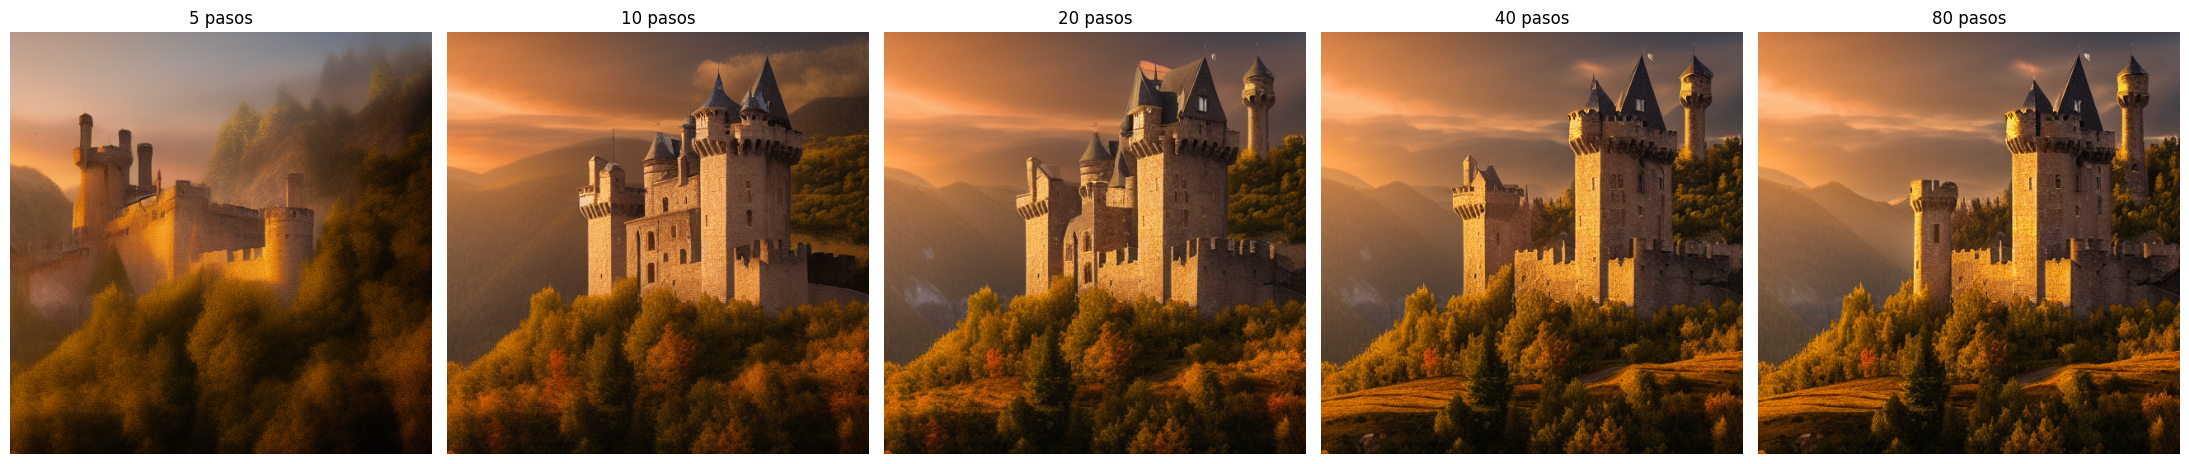

Comparación guardada en: /content/Actividad3_PasosInferencia/comparacion_pasos.png


In [7]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, imagen, pasos in zip(axes, imagenes, STEP_VALUES):
    ax.imshow(imagen)
    ax.set_title(f"{pasos} pasos")
    ax.axis("off")

plt.tight_layout()
ruta = CARPETA_RESULTADOS / "comparacion_pasos.png"
plt.savefig(ruta, dpi=150, bbox_inches="tight")
plt.show()

print("Comparación guardada en:", ruta)


# 8. Medición del tiempo

In [8]:
tabla_resultados = pd.DataFrame({
    "Pasos": STEP_VALUES,
    "Tiempo de generación (s)": [round(t, 2) for t in tiempos]
})
tabla_resultados["Incremento respecto al anterior (s)"] = (
    tabla_resultados["Tiempo de generación (s)"].diff().round(2)
)
tabla_resultados


,Pasos,Tiempo de generación (s),Incremento respecto al anterior (s)
0,5,8.13,NaN
1,10,4.81,-3.32
2,20,6.79,1.98
3,40,10.35,3.56
4,80,19.32,8.97


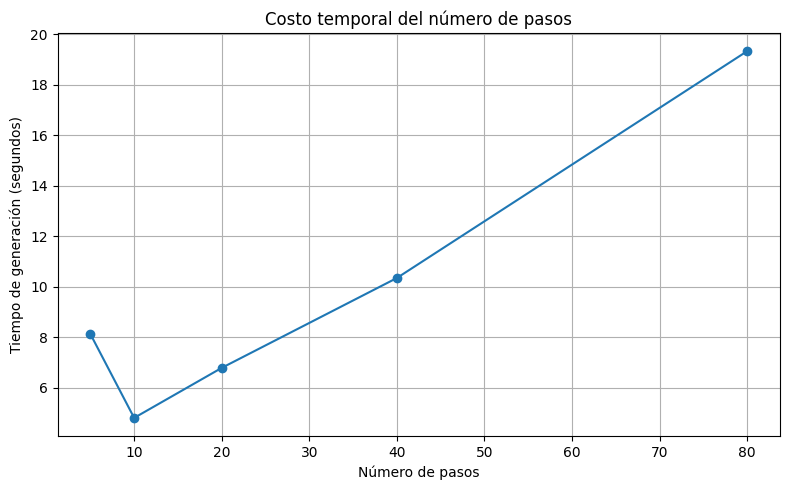

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(STEP_VALUES, tiempos, marker="o")
plt.xlabel("Número de pasos")
plt.ylabel("Tiempo de generación (segundos)")
plt.title("Costo temporal del número de pasos")
plt.grid(True)
plt.tight_layout()

ruta = CARPETA_RESULTADOS / "tiempo_vs_pasos.png"
plt.savefig(ruta, dpi=150, bbox_inches="tight")
plt.show()


# 9. Registro de observaciones

| Pasos | Coherencia | Nitidez | Detalle | Calidad percibida | Observaciones |
|---:|---:|---:|---:|---:|---|
| 5 | | | | | |
| 10 | | | | | |
| 20 | | | | | |
| 40 | | | | | |
| 80 | | | | | |


# 10. Preguntas de análisis

1. ¿En qué valor apareció una imagen utilizable?
2. ¿Entre qué valores observaste la mayor mejora?
3. ¿La diferencia entre 40 y 80 justificó el tiempo adicional?
4. ¿El tiempo creció aproximadamente con el número de pasos?
5. ¿Qué valor elegirías para una generación rápida?
6. ¿Qué valor usarías para una imagen final?
7. Concluye: “Aumentar los pasos de inferencia...”


## Reflexión

> “Los pasos son oportunidades de refinamiento, pero cada paso adicional aporta menos que el anterior.”


# 11. Mini reto: encuentra el equilibrio

Elige un valor entre **12 y 35 pasos**.

Objetivo:

- producir una imagen aceptable;
- tardar menos que con 40 pasos;
- conservar suficiente detalle.


  0%|          | 0/20 [00:00<?, ?it/s]

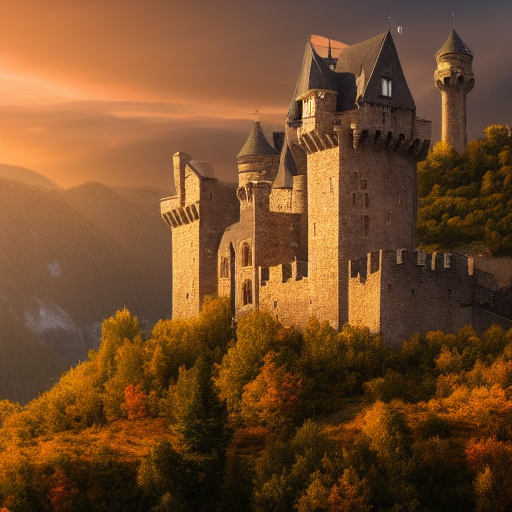

Pasos utilizados: 20
Tiempo: 6.05 segundos


In [19]:
PASOS_RETO = 20 # Modifica solo este valor

imagen_reto, tiempo_reto = generar_imagen(PASOS_RETO)
display(imagen_reto)

print(f"Pasos utilizados: {PASOS_RETO}")
print(f"Tiempo: {tiempo_reto:.2f} segundos")


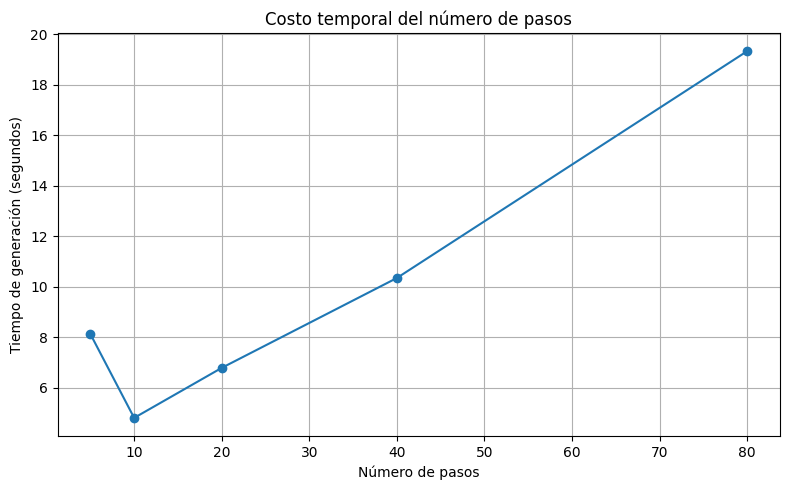

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(STEP_VALUES, tiempos, marker="o")
plt.xlabel("Número de pasos")
plt.ylabel("Tiempo de generación (segundos)")
plt.title("Costo temporal del número de pasos")
plt.grid(True)
plt.tight_layout()

ruta = CARPETA_RESULTADOS / "tiempo_vs_pasos.png"
plt.savefig(ruta, dpi=150, bbox_inches="tight")
plt.show()

## Reflexión del mini reto

- Valor elegido:
- Razón:
- Calidad obtenida:
- Tiempo obtenido:
- ¿Fue mejor decisión que usar 40 pasos?
- ¿Qué cambiarías en otra prueba?


# 12. Evidencia de aprendizaje

Entrega:

1. comparación de las cinco imágenes;
2. tabla de observaciones;
3. tabla de tiempos;
4. gráfica tiempo versus pasos;
5. imagen del mini reto;
6. conclusión personal de máximo 100 palabras.




# 13. Cierre conceptual

- Muy pocos pasos: menor refinamiento.
- Pasos intermedios: buena relación calidad-tiempo.
- Muchos pasos: mayor costo y mejoras cada vez menores.

> **Más pasos no significa automáticamente una imagen proporcionalmente mejor.**
